In [ ]:
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '../../'))
sys.path.append(parent_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as opt
from torch.utils.data import Dataset, DataLoader, TensorDataset

from models.oneD_unet_cond import Unet
from ddpm.OneD_ddpm import DDPM
from torch.optim import Adam

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

## Data
seq_len = 336
batch_size = 128

#NN
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cond_model = "mlp"
lr = 1e-4
betas = (0.9, 0.99)
epochs = 5000
save_rate = 50

## DDPM
timesteps = 1000

save_name = f"rq_1/unet_{seq_len}_3"
weights_dir = "./logging/rq1_336/unet_cond_5kepochs_336seq_2/weights/best_model.pth"

In [ ]:
if not os.path.isdir(f"./logging/eval/{save_name}"):
    os.makedirs(f"./logging/eval/{save_name}")

# Utils

In [ ]:
PREPROCESSED_DIR = "./preprocessing/data/customer_led_network_revolution/preprocessed/"

In [ ]:
def time_fe(df, timestamps, seq_len):
    num_customer = df.shape[0]
    conditioning_data = np.zeros((num_customer, 4, seq_len)) #4 is the number of features you want to extract

    for i in range(num_customer):
        customer_start_date = timestamps[i]
        for j in range(seq_len):
            current_date = customer_start_date + pd.Timedelta(days=j)
            
            day = current_date.day
            hour = current_date.hour
            minute = current_date.minute
            is_weekend = int(day in([5, 6]))
            
            day_sin = np.sin(2 * np.pi * day / 7)
            hour_sin = np.sin(2 * np.pi * hour / 24)
            minute_sin = np.sin(2 * np.pi * minute / 60)
        
            conditioning_data[i, 0, j] = day_sin
            conditioning_data[i, 1, j] = hour_sin
            conditioning_data[i, 2, j] = minute_sin
            conditioning_data[i, 3, j] = is_weekend

    return conditioning_data

# Load Data

In [ ]:
train = pd.read_csv(os.path.join(PREPROCESSED_DIR, "train.csv"), index_col="Location ID")
val = pd.read_csv(os.path.join(PREPROCESSED_DIR, "val.csv"), index_col="Location ID")
test = pd.read_csv(os.path.join(PREPROCESSED_DIR, "test.csv"), index_col="Location ID")

In [ ]:
train_seq = train.iloc[:, :seq_len]
train_time = pd.to_datetime(train.columns, format='%d/%m/%Y %H:%M:%S')
train_con = time_fe(train_seq, train_time, seq_len)
train_seq = np.asarray(train_seq).reshape(train_seq.shape[0], 1, train_seq.shape[1])
train_seq.shape, train_con.shape

((3037, 1, 336), (3037, 4, 336))

In [ ]:
val_seq = val.iloc[:, :seq_len]
val_time = pd.to_datetime(val.columns, format='%d/%m/%Y %H:%M:%S')
val_con = time_fe(val_seq, val_time, seq_len)
val_seq = np.asarray(val_seq).reshape(val_seq.shape[0], 1, val_seq.shape[1])
val_seq.shape, val_con.shape

((537, 1, 336), (537, 4, 336))

In [ ]:
test_seq = test.iloc[:, :seq_len]
test_time = pd.to_datetime(test.columns, format='%d/%m/%Y %H:%M:%S')
test_con = time_fe(test_seq, test_time, seq_len)
test_seq = np.asarray(test_seq).reshape(test_seq.shape[0], 1, test_seq.shape[1])
test_seq.shape, test_con.shape

((894, 1, 336), (894, 4, 336))

In [ ]:
train_dataset = TensorDataset(torch.from_numpy(train_seq), torch.from_numpy(train_con))
train_loader = DataLoader(train_dataset, batch_size, shuffle=False)

val_dataset = TensorDataset(torch.from_numpy(val_seq), torch.from_numpy(val_con))
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

test_dataset = TensorDataset(torch.from_numpy(test_seq), torch.from_numpy(test_con))
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

In [ ]:
model = Unet(
    in_channels=train_seq.shape[1],
    out_channels=train_seq.shape[1],
    time_embedding_dim=32,
    base_channels=32,
    channel_mults=(1, 2, 4),
    cond_in_channels=train_con.shape[1],
    cond_sequence_length=seq_len, # Pass sequence length for MLP conditioner
    cond_embedding_dim=32
)

ddpm = DDPM(
        model=model,
        timesteps=timesteps,
        device=device
    )

optim = Adam(model.parameters(), lr=lr)

ddpm.model.load_state_dict(torch.load(weights_dir)["diffusion_state_dict"])

C:\Users\Arne\AppData\Local\Temp\ipykernel_1988\2416798049.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ddpm.model.load_state_dict(torch.load(weights_dir)["diffusion

In [ ]:
batch_size

128

In [ ]:
real_data_train = []
generated_data_train = []

for idx, (data, cond) in enumerate(train_loader):
    if idx == 10000:
        break
    
    if cond.shape[0] == data.shape[0] == batch_size:
        real_data_train.append(data)
        
        with torch.no_grad():
            samples = ddpm.sample(batch_size, seq_len=seq_len, features=data.shape[1])
            samples = samples.cpu().numpy()
        
        generated_data_train.append(samples)
    
generated_data = np.concatenate(generated_data_train, axis=0)
real_data = np.concatenate(real_data_train, axis=0)

generated_tensor = torch.tensor(generated_data, dtype=torch.float32)
real_tensor = torch.tensor(real_data, dtype=torch.float32)

generated_labels = torch.zeros(len(generated_tensor), dtype=torch.long)
real_labels = torch.ones(len(real_tensor), dtype=torch.long)

all_samples_train = torch.cat([generated_tensor, real_tensor], dim=0)
all_labels_train = torch.cat([generated_labels, real_labels], dim=0)

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 98.08it/s]


In [ ]:
real_data_test = []
generated_data_test = []

for idx, (data, cond) in enumerate(test_loader):
    if idx == 3000:
        break
    if cond.shape[0] == data.shape[0] == batch_size:
        real_data_test.append(data)

        with torch.no_grad():
            samples = ddpm.sample(batch_size, seq_len=seq_len, features=data.shape[1])
            samples = samples.cpu().numpy()
        
        generated_data_test.append(samples)
    
generated_data = np.concatenate(generated_data_test, axis=0)
real_data = np.concatenate(real_data_test, axis=0)

generated_tensor = torch.tensor(generated_data, dtype=torch.float32)
real_tensor = torch.tensor(real_data, dtype=torch.float32)

generated_labels = torch.zeros(len(generated_tensor), dtype=torch.long)
real_labels = torch.ones(len(real_tensor), dtype=torch.long)

all_samples_test = torch.cat([generated_tensor, real_tensor], dim=0)
all_labels_test = torch.cat([generated_labels, real_labels], dim=0)

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 95.89it/s]


In [ ]:
class RealVsSyntheticDataset(Dataset):
    def __init__(self, samples, labels):
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [ ]:
dataset = RealVsSyntheticDataset(all_samples_train, all_labels_train)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

for x, y in train_loader:
    print(x.shape)  # (64, 1, 336)
    print(y.shape)  # (64,)
    break

torch.Size([64, 1, 336])
torch.Size([64])


# Model
## LSTM

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, num_layers=2):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        # x: (batch_size, seq_len=15, input_dim=12)
        lstm_out, _ = self.lstm(x)  
        last_hidden = lstm_out[:, -1, :]
        out = self.fc(last_hidden)      
        return out

## Transformer

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=48, num_heads=2, hidden_dim=64, num_layers=2, seq_len=15):
        super(TransformerClassifier, self).__init__()

        self.embedding = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim,
                                                   nhead=num_heads,
                                                   batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        # x: (batch, seq_len=15, input_dim=12)
        x = self.embedding(x) 
        x = self.transformer(x) 

        # Pool over the sequence dimension
        x = x.permute(0, 2, 1)  
        x = self.pool(x).squeeze(-1) 

        out = self.fc(x) 
        return out

In [ ]:
model = TransformerClassifier(input_dim=seq_len)
#model = LSTMClassifier()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = opt.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.2f}%")

Epoch 1/10 - Loss: 0.4056 - Accuracy: 81.01%
Epoch 2/10 - Loss: 0.1513 - Accuracy: 94.51%
Epoch 3/10 - Loss: 0.1204 - Accuracy: 95.75%
Epoch 4/10 - Loss: 0.0968 - Accuracy: 96.33%
Epoch 5/10 - Loss: 0.0777 - Accuracy: 97.08%
Epoch 6/10 - Loss: 0.0698 - Accuracy: 97.59%
Epoch 7/10 - Loss: 0.0586 - Accuracy: 97.66%
Epoch 8/10 - Loss: 0.0446 - Accuracy: 98.39%
Epoch 9/10 - Loss: 0.0455 - Accuracy: 98.30%
Epoch 10/10 - Loss: 0.0587 - Accuracy: 97.64%


In [ ]:
def evaluate(model, dataloader, device, save_name, plot=True):
    model.eval()
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            probs = torch.softmax(outputs, dim=1)[:, 1]  # probability for "synthetic" class
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100
    
    with open(f"./logging/eval/{save_name}/res.txt", "w") as f:
        f.write(str(accuracy))

    if plot:
        all_labels = torch.tensor(all_labels)
        all_preds = torch.tensor(all_preds)
        all_probs = torch.tensor(all_probs)

        # 1. Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Synthetic"])
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.savefig(f'./logging/eval/{save_name}/conf.png')
        plt.show()

        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'./logging/eval/{save_name}/ROC.png')
        plt.show()

        # 3. Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(all_labels, all_probs)
        plt.figure()
        plt.plot(recall, precision, label='PR Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.grid(True)
        plt.legend()
        plt.savefig(f'./logging/eval/{save_name}/PR.png')
        plt.show()

    return f"Model Test Accuracy: {accuracy}"

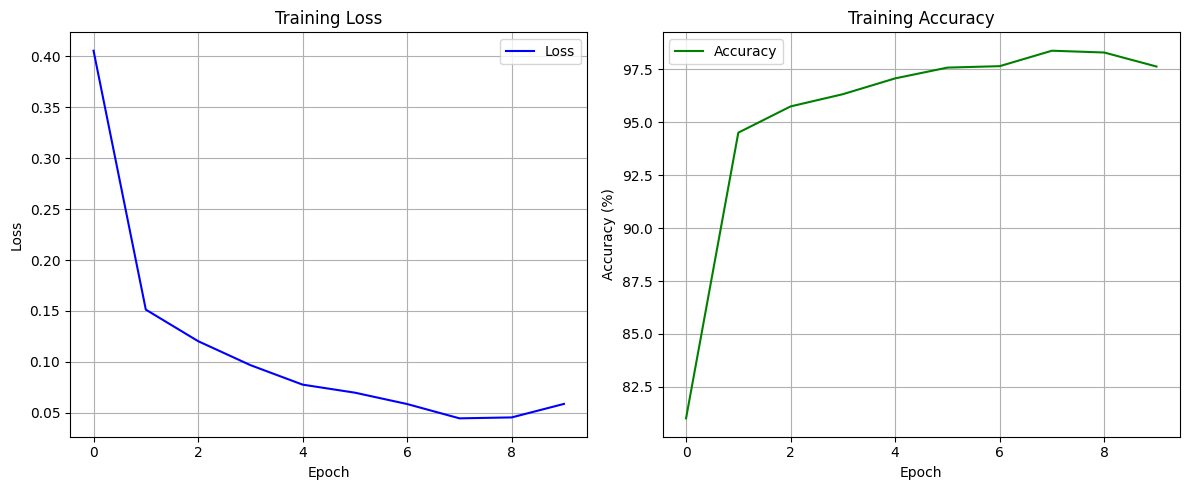

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Loss", color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Eval

In [ ]:
dataset = RealVsSyntheticDataset(all_samples_test, all_labels_test)
test_loader = DataLoader(dataset, batch_size=64, shuffle=True)

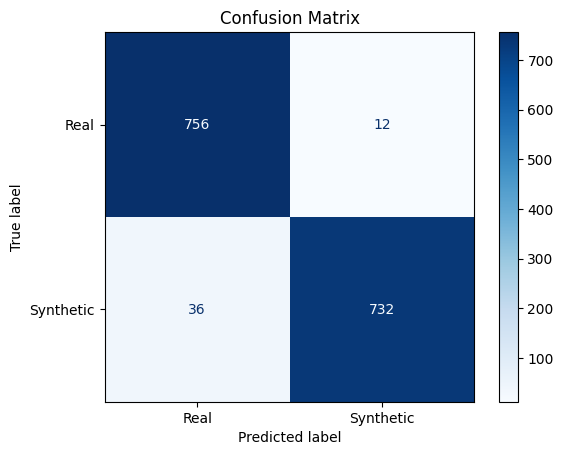

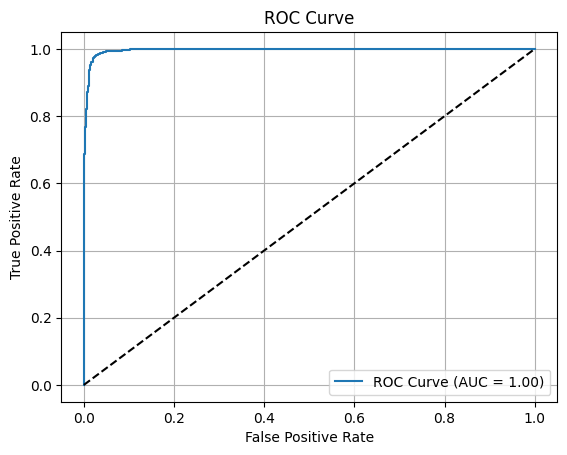

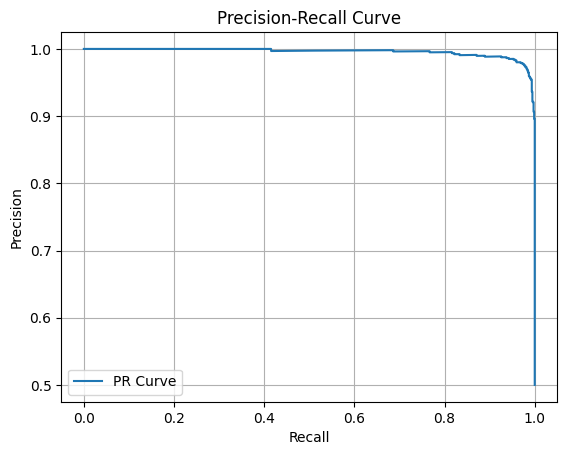

'Model Test Accuracy: 96.875'

In [ ]:
evaluate(model, test_loader, device, save_name=save_name)